In [249]:
import pandas as pd

In [250]:
df=pd.read_csv('bank-additional-full.csv')

In [251]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [252]:
df.shape

(41188, 21)

In [253]:
df[df.duplicated(keep=False)]
df=df.drop_duplicates()

In [254]:
df['pdays'].unique()

array([999,   6,   4,   3,   5,   1,   0,  10,   7,   8,   9,  11,   2,
        12,  13,  14,  15,  16,  21,  17,  18,  22,  25,  26,  19,  27,
        20])

In [255]:
# Convert 'pdays' column into categorical data
def categorize_pdays(p):
    if p == 999:
        return 'no contact'
    elif 0 <= p <= 7:
        return 'recent'
    elif 8 <= p <= 20:
        return 'moderate'
    else:
        return 'long ago'

df['pdays_category'] = df['pdays'].apply(categorize_pdays)

In [256]:
df['pdays_category'].value_counts()

,count
pdays_category,
no contact,39661
recent,1177
moderate,330
long ago,8


In [257]:
df.drop('pdays', axis=1, inplace=True)

In [258]:
df['default'].value_counts()

,count
default,
no,32577
unknown,8596
yes,3


In [259]:
df['education'].value_counts()

,count
education,
university.degree,12164
high.school,9512
basic.9y,6045
professional.course,5240
basic.4y,4176
basic.6y,2291
unknown,1730
illiterate,18


In [260]:
import numpy as np

In [261]:
df_cat = df.select_dtypes(exclude=np.number)

In [262]:
df_cat

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y,pdays_category
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent,no,no contact
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent,no,no contact
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent,no,no contact
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent,no,no contact
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent,no,no contact
...,...,...,...,...,...,...,...,...,...,...,...,...
41183,retired,married,professional.course,no,yes,no,cellular,nov,fri,nonexistent,yes,no contact
41184,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,no,no contact
41185,retired,married,university.degree,no,yes,no,cellular,nov,fri,nonexistent,no,no contact
41186,technician,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,yes,no contact


In [263]:
import matplotlib.pyplot as plt
import seaborn as sns

In [264]:
df['y'].value_counts()/len(df)

,count
y,
no,0.887337
yes,0.112663


Since the class 'no' contributes to over 80% of the data we can conclude that the data is imbalanced.

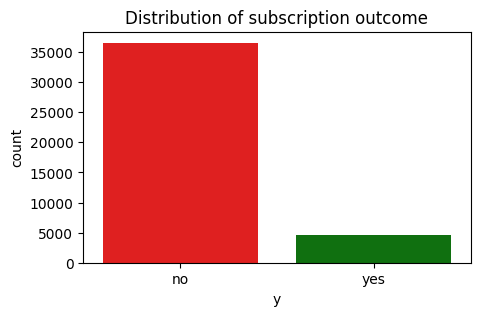

In [265]:
# Target variable distribution
plt.figure(figsize=(5, 3))
sns.countplot(x=df['y'],hue=df['y'],palette=['red','green'],legend=False)
plt.title('Distribution of subscription outcome')
plt.show()

From the plot it is clear that the data is imbalanced.

In [266]:
import warnings
warnings.filterwarnings('ignore')

<Axes: xlabel='campaign', ylabel='Density'>

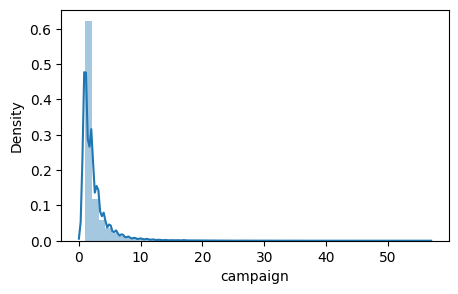

In [267]:
plt.figure(figsize=(5, 3))
sns.distplot(df['campaign'])

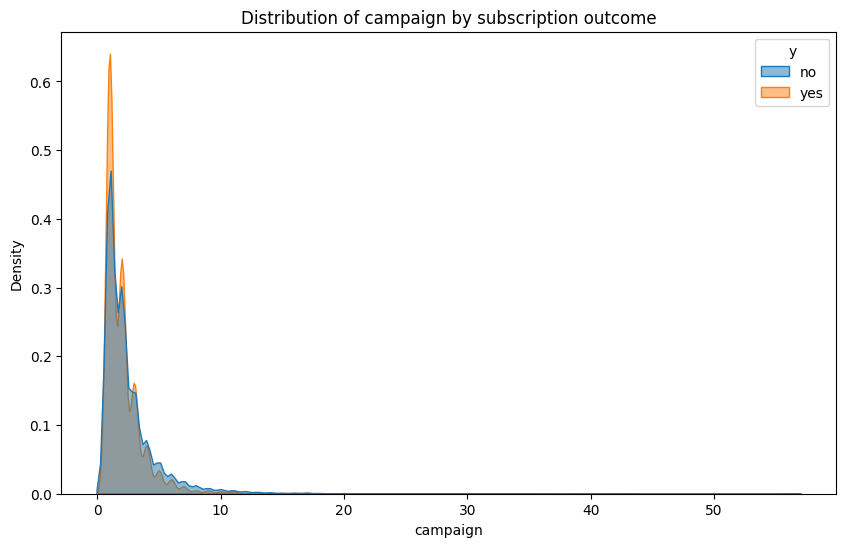

In [268]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='campaign', hue='y', fill=True, common_norm=False, alpha=0.5)
plt.title('Distribution of campaign by subscription outcome')
plt.show()

<Axes: xlabel='age', ylabel='Density'>

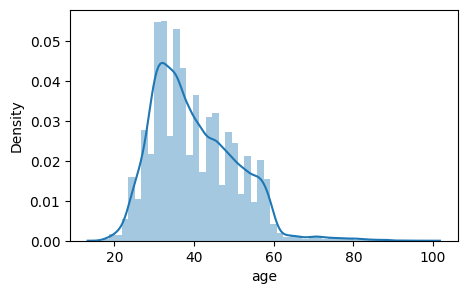

In [269]:
plt.figure(figsize=(5, 3))
sns.distplot(df['age'])

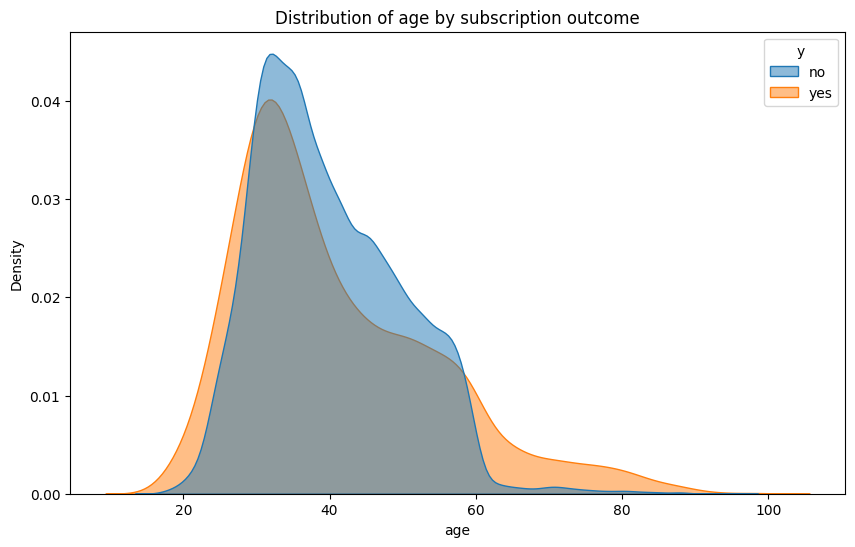

In [270]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='age', hue='y', fill=True, common_norm=False, alpha=0.5)
plt.title('Distribution of age by subscription outcome')
plt.show()

<Axes: xlabel='duration', ylabel='Density'>

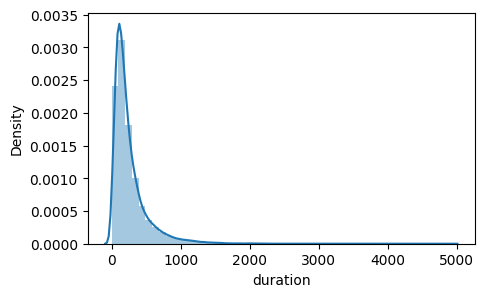

In [271]:
plt.figure(figsize=(5, 3))
sns.distplot(df['duration'])

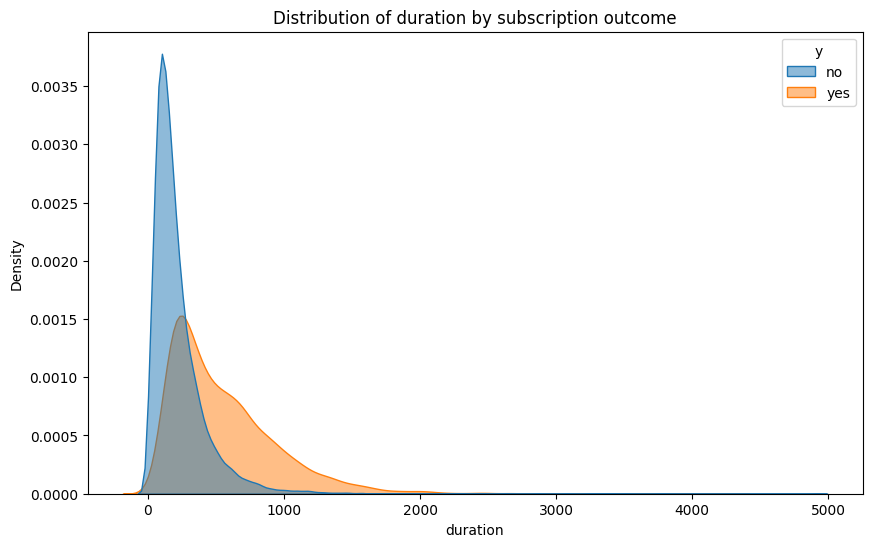

In [272]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='duration', hue='y', fill=True, common_norm=False, alpha=0.5)
plt.title('Distribution of duration by subscription outcome')
plt.show()

<Axes: xlabel='previous', ylabel='Density'>

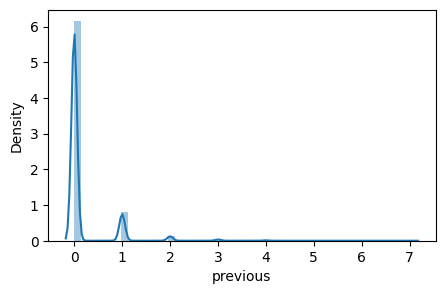

In [273]:
plt.figure(figsize=(5, 3))
sns.distplot(df['previous'])

<Axes: xlabel='previous', ylabel='Count'>

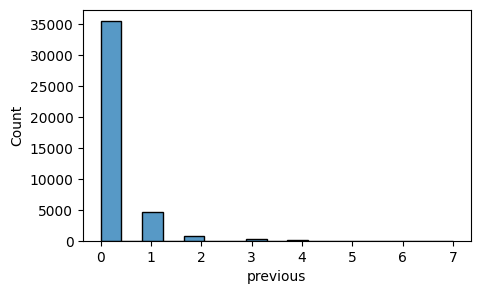

In [274]:
plt.figure(figsize=(5, 3))
sns.histplot(df['previous'])

<Axes: xlabel='previous', ylabel='count'>

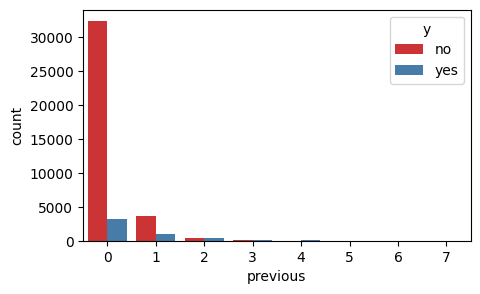

In [275]:
plt.figure(figsize=(5, 3))
sns.countplot(data=df,x='previous',hue='y',palette='Set1')

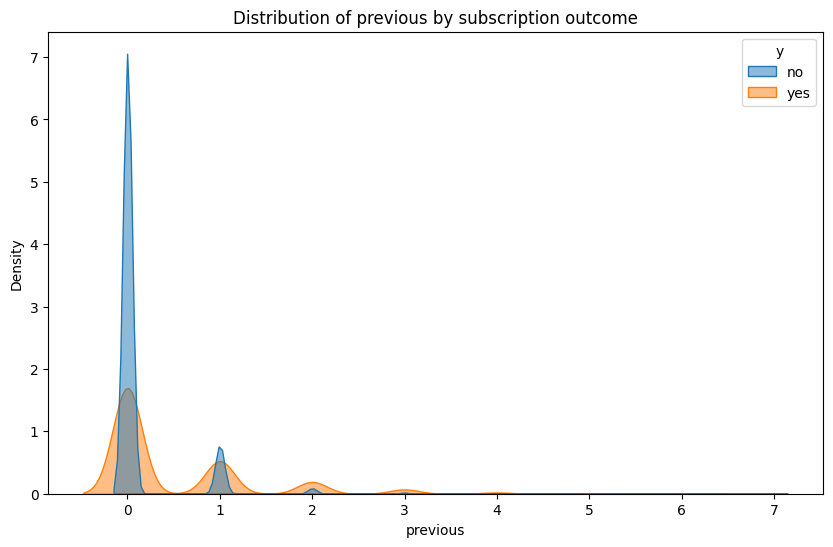

In [276]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='previous', hue='y', fill=True, common_norm=False, alpha=0.5)
plt.title('Distribution of previous by subscription outcome')
plt.show()

<Axes: xlabel='emp.var.rate', ylabel='Density'>

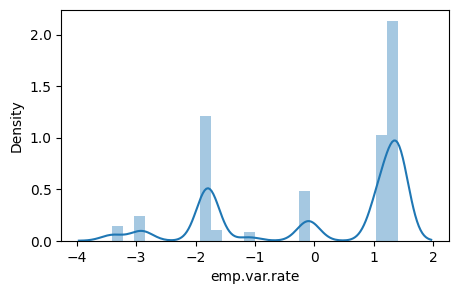

In [277]:
plt.figure(figsize=(5, 3))
sns.distplot(df['emp.var.rate'])

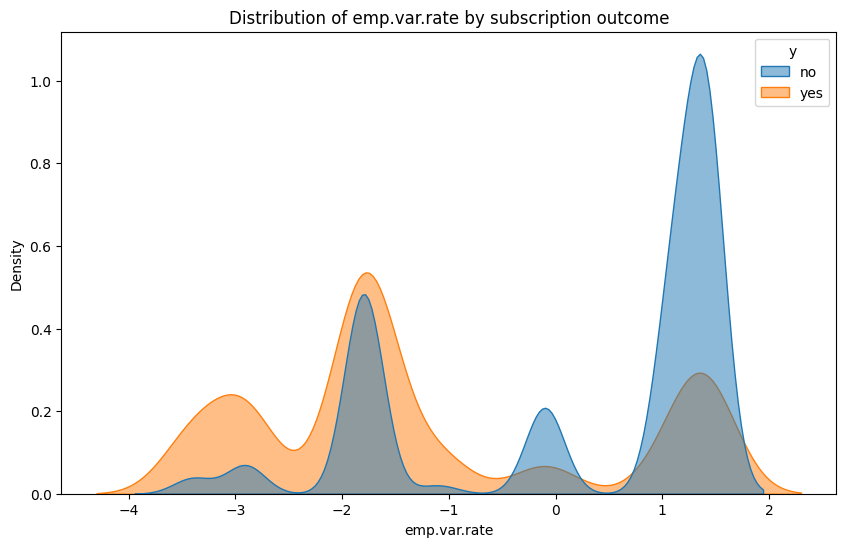

In [278]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='emp.var.rate', hue='y', fill=True, common_norm=False, alpha=0.5)
plt.title('Distribution of emp.var.rate by subscription outcome')
plt.show()

<Axes: xlabel='cons.price.idx', ylabel='Density'>

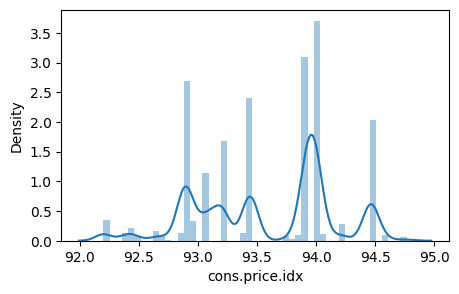

In [279]:
plt.figure(figsize=(5, 3))
sns.distplot(df['cons.price.idx'])

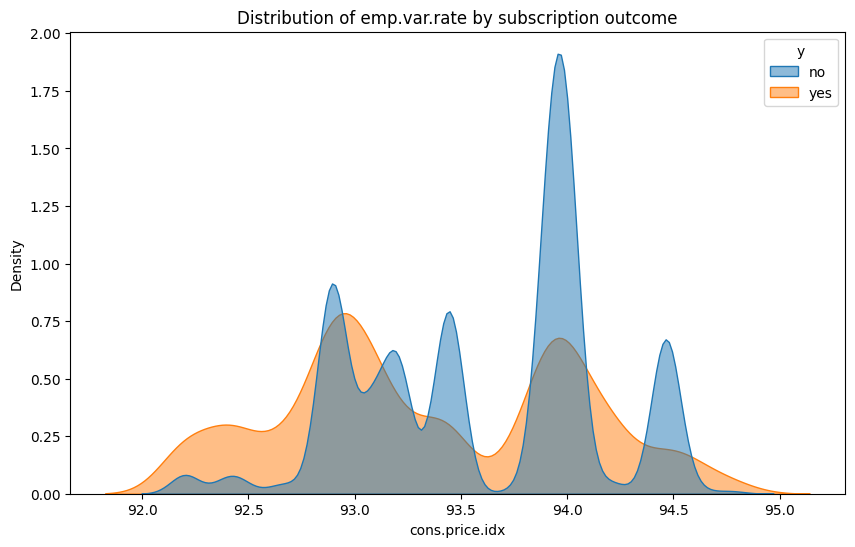

In [280]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='cons.price.idx', hue='y', fill=True, common_norm=False, alpha=0.5)
plt.title('Distribution of emp.var.rate by subscription outcome')
plt.show()

<Axes: xlabel='cons.conf.idx', ylabel='Density'>

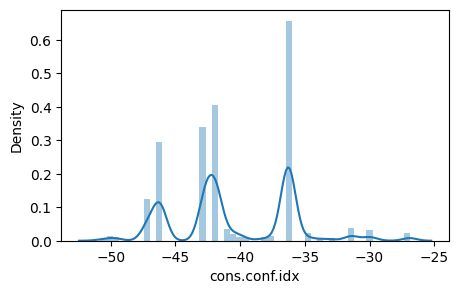

In [281]:
plt.figure(figsize=(5, 3))
sns.distplot(df['cons.conf.idx'])

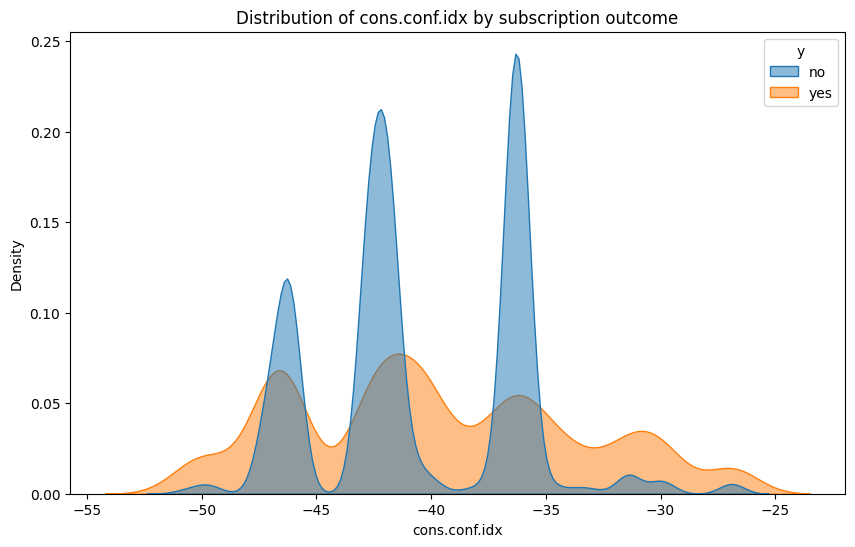

In [282]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='cons.conf.idx', hue='y', fill=True, common_norm=False, alpha=0.5)
plt.title('Distribution of cons.conf.idx by subscription outcome')
plt.show()

<Axes: xlabel='euribor3m', ylabel='Density'>

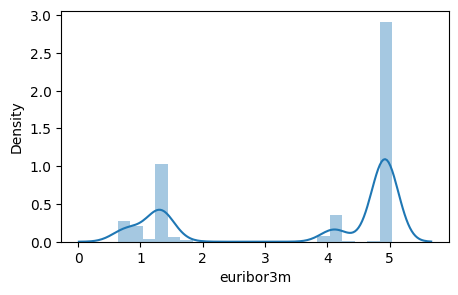

In [283]:
plt.figure(figsize=(5, 3))
sns.distplot(df['euribor3m'])

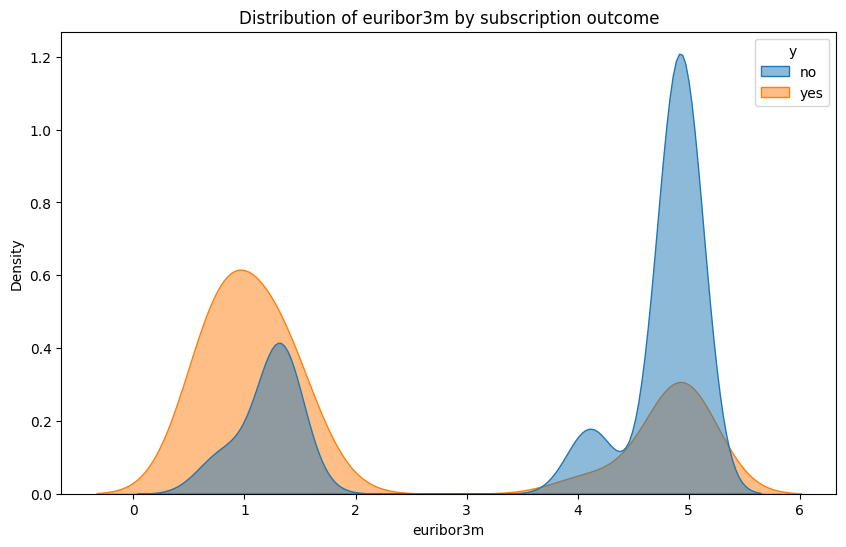

In [284]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='euribor3m', hue='y', fill=True, common_norm=False, alpha=0.5)
plt.title('Distribution of euribor3m by subscription outcome')
plt.show()

<Axes: xlabel='nr.employed', ylabel='Density'>

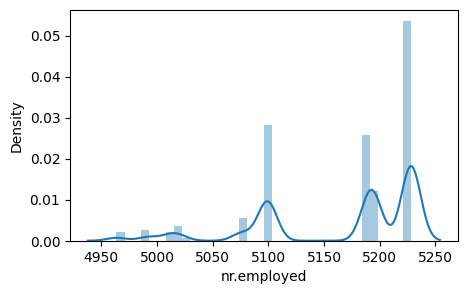

In [285]:
plt.figure(figsize=(5, 3))
sns.distplot(df['nr.employed'])

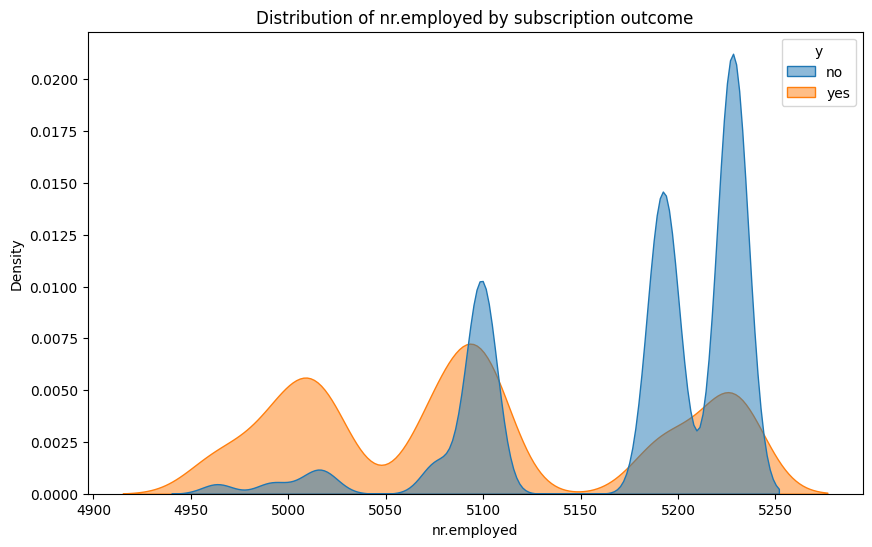

In [286]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='nr.employed', hue='y', fill=True, common_norm=False, alpha=0.5)
plt.title('Distribution of nr.employed by subscription outcome')
plt.show()

In [287]:
df.describe()

,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


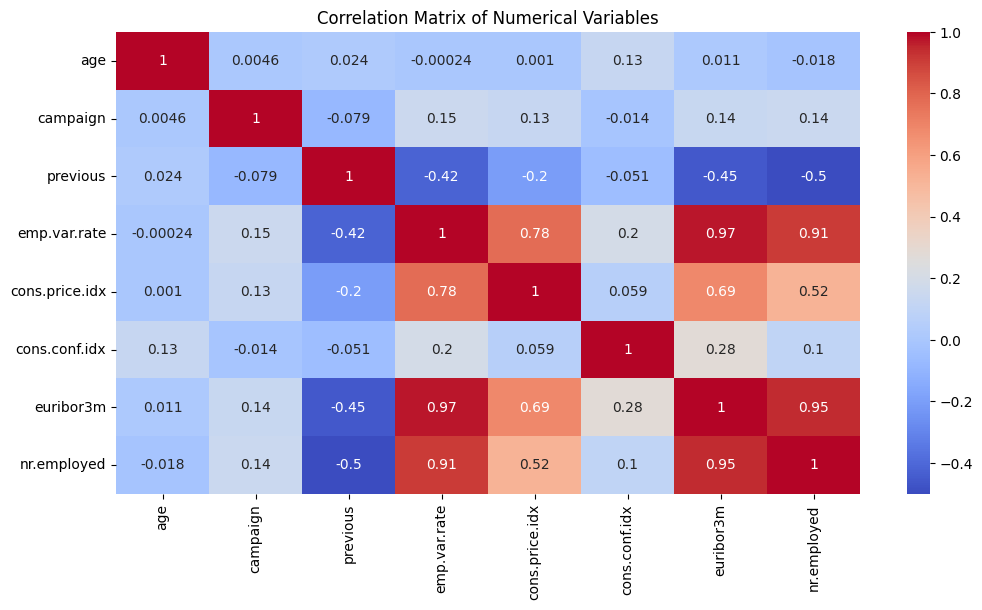

In [288]:
numeric_cols = ['age', 'campaign', 'previous',
                'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
plt.figure(figsize=(12,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

<Axes: xlabel='pdays_category', ylabel='count'>

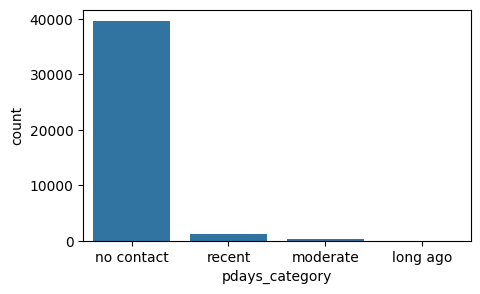

In [289]:
plt.figure(figsize=(5,3))
sns.countplot(data=df, x='pdays_category')

<Axes: xlabel='pdays_category', ylabel='count'>

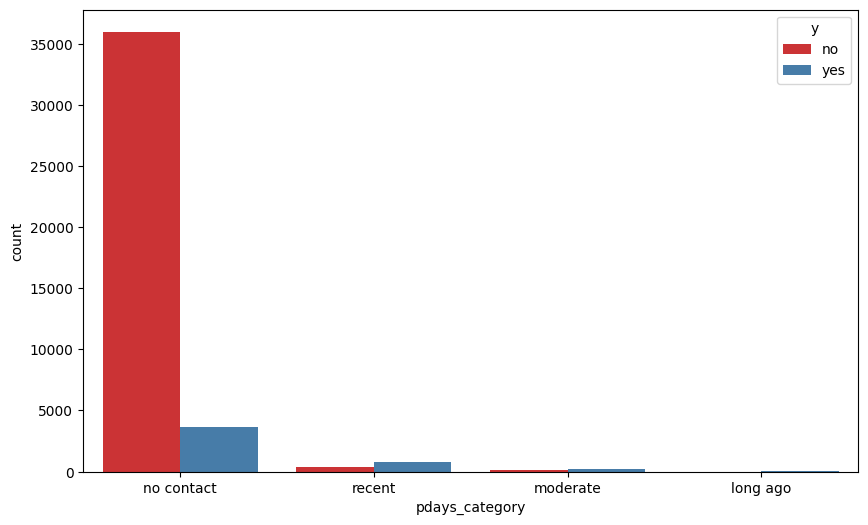

In [290]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df,x='pdays_category',hue='y',palette='Set1')

<Axes: xlabel='education', ylabel='count'>

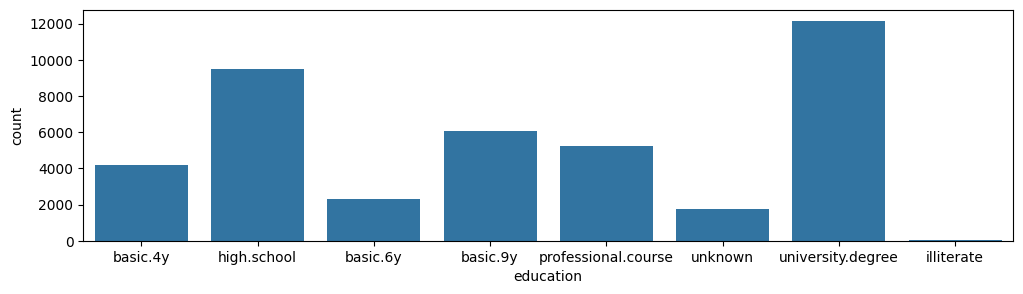

In [291]:
plt.figure(figsize=(12,3))
sns.countplot(data=df, x='education')

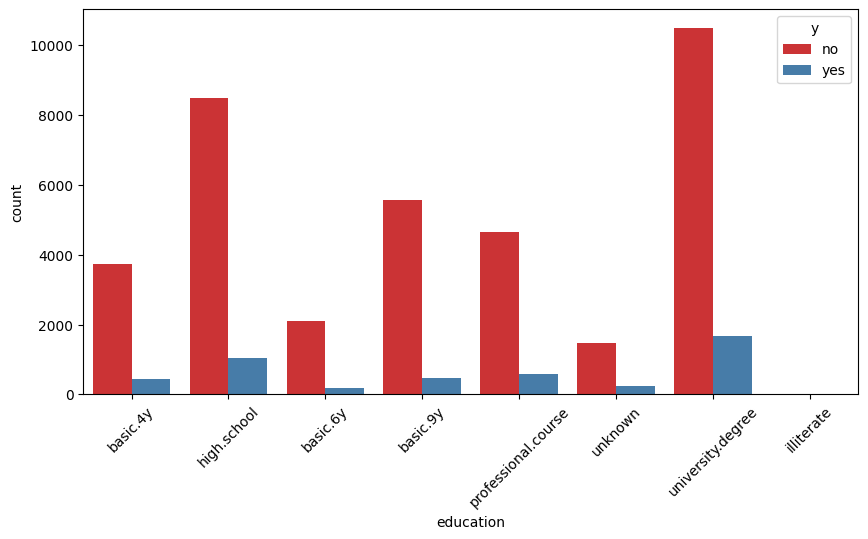

In [292]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='education', hue='y',palette='Set1')
plt.gca().tick_params(axis='x', rotation=45)

<Axes: xlabel='job', ylabel='count'>

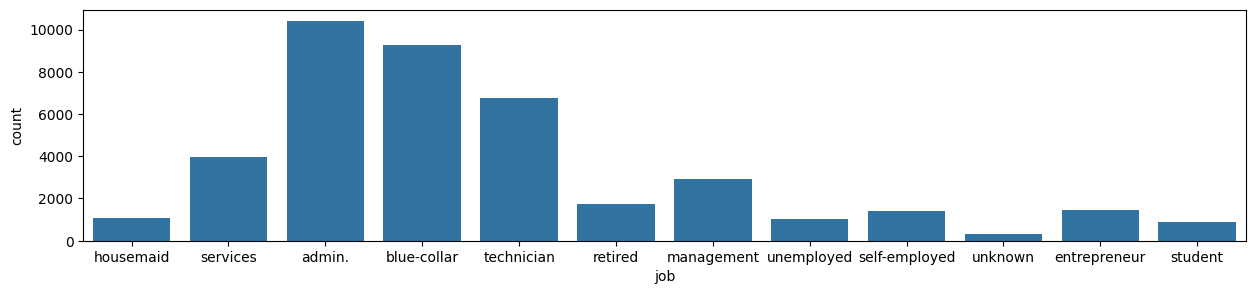

In [293]:
plt.figure(figsize=(15,3))
sns.countplot(data=df, x='job')

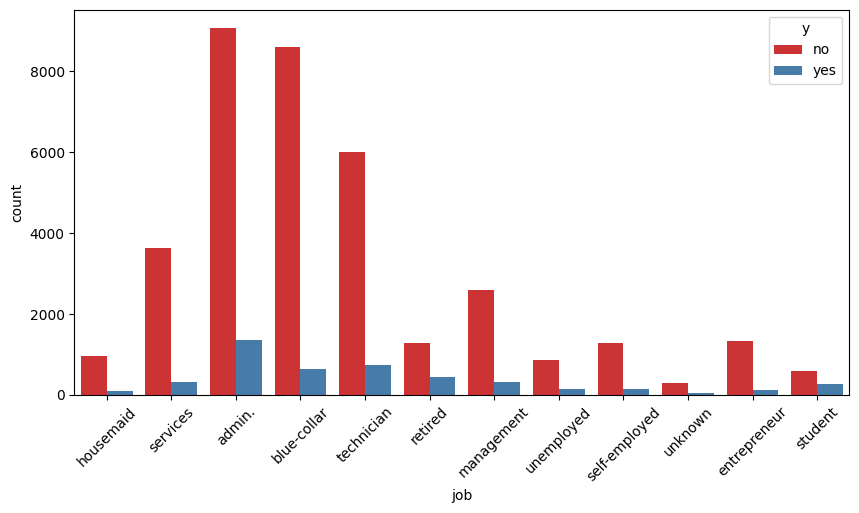

In [294]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='job', hue='y',palette='Set1')
plt.gca().tick_params(axis='x', rotation=45)

<Axes: xlabel='marital', ylabel='count'>

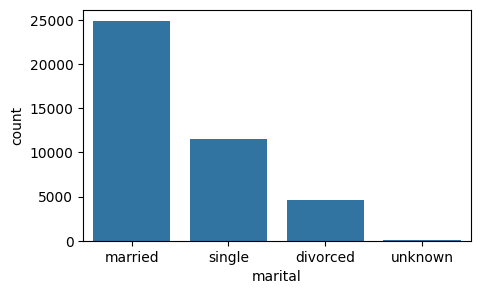

In [295]:
plt.figure(figsize=(5,3))
sns.countplot(data=df, x='marital')

<Axes: xlabel='marital', ylabel='count'>

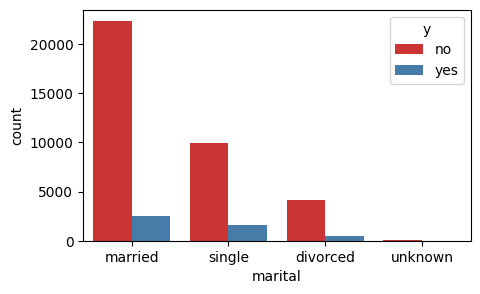

In [296]:
plt.figure(figsize=(5,3))
sns.countplot(data=df,x='marital', hue='y',palette='Set1')

<Axes: xlabel='default', ylabel='count'>

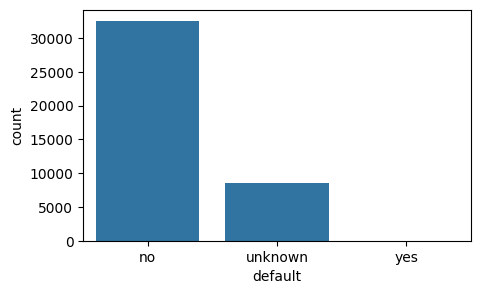

In [297]:
plt.figure(figsize=(5,3))
sns.countplot(data=df, x='default')

<Axes: xlabel='default', ylabel='count'>

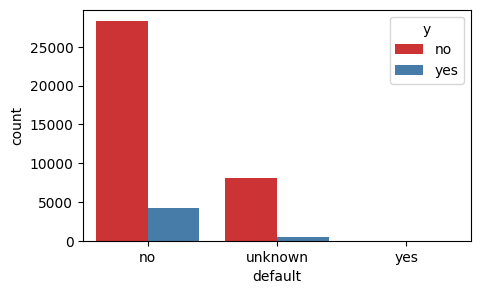

In [298]:
plt.figure(figsize=(5,3))
sns.countplot(data=df,x='default', hue='y',palette='Set1')

<Axes: xlabel='housing', ylabel='count'>

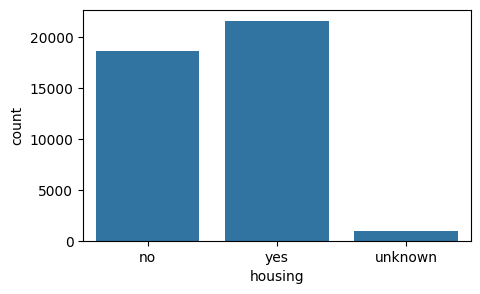

In [299]:
plt.figure(figsize=(5,3))
sns.countplot(data=df, x='housing')

<Axes: xlabel='housing', ylabel='count'>

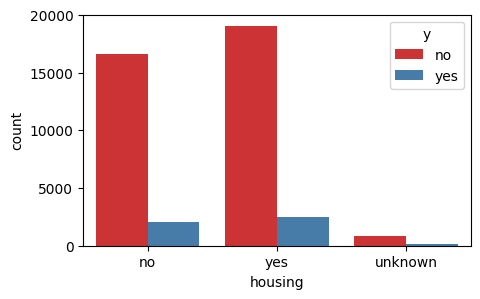

In [300]:
plt.figure(figsize=(5,3))
sns.countplot(data=df,x='housing', hue='y',palette='Set1')

<Axes: xlabel='loan', ylabel='count'>

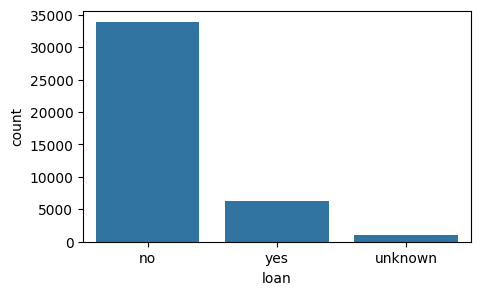

In [301]:
plt.figure(figsize=(5,3))
sns.countplot(data=df, x='loan')

<Axes: xlabel='loan', ylabel='count'>

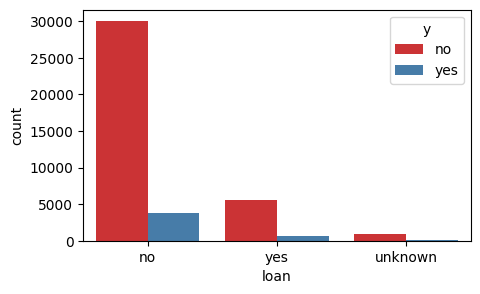

In [302]:
plt.figure(figsize=(5,3))
sns.countplot(data=df,x='loan', hue='y',palette='Set1')

<Axes: xlabel='contact', ylabel='count'>

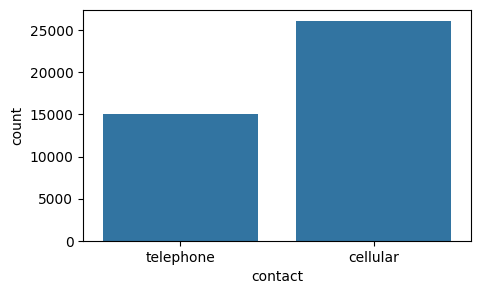

In [303]:
plt.figure(figsize=(5,3))
sns.countplot(data=df, x='contact')

<Axes: xlabel='contact', ylabel='count'>

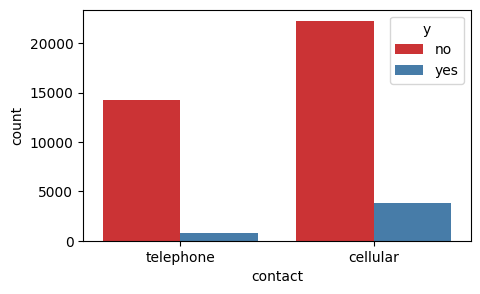

In [304]:
plt.figure(figsize=(5,3))
sns.countplot(data=df,x='contact', hue='y',palette='Set1')

<Axes: xlabel='month', ylabel='count'>

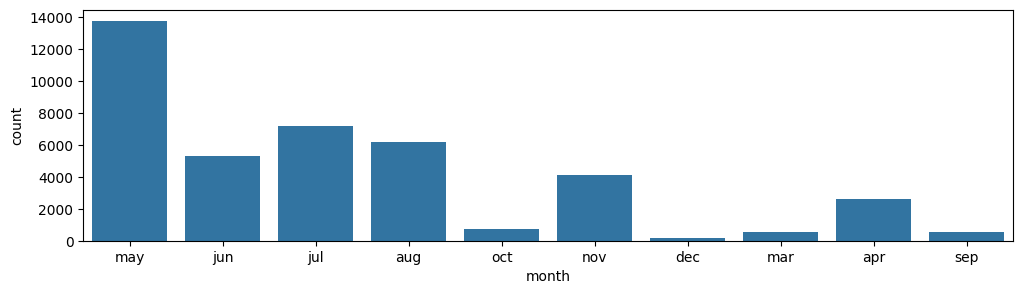

In [305]:
plt.figure(figsize=(12,3))
sns.countplot(data=df, x='month')

<Axes: xlabel='month', ylabel='count'>

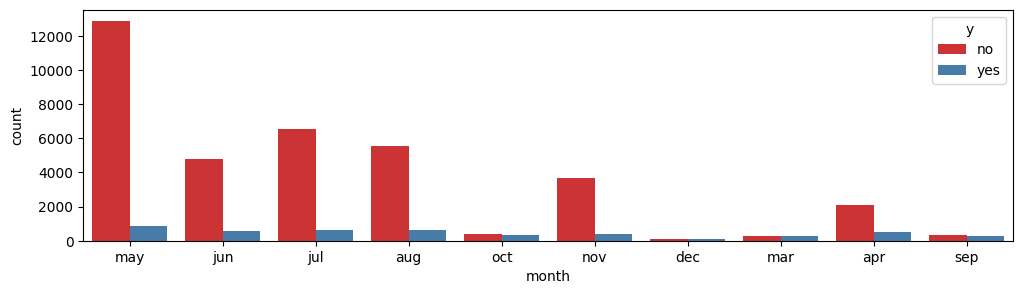

In [306]:
plt.figure(figsize=(12,3))
sns.countplot(data=df,x='month', hue='y',palette='Set1')

<Axes: xlabel='day_of_week', ylabel='count'>

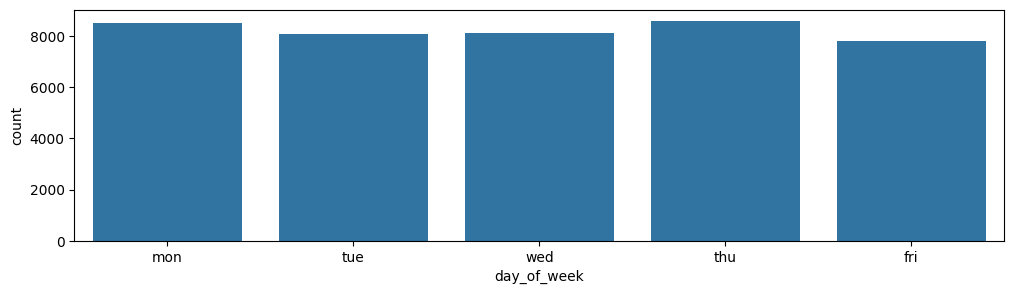

In [307]:
plt.figure(figsize=(12,3))
sns.countplot(data=df, x='day_of_week')

<Axes: xlabel='day_of_week', ylabel='count'>

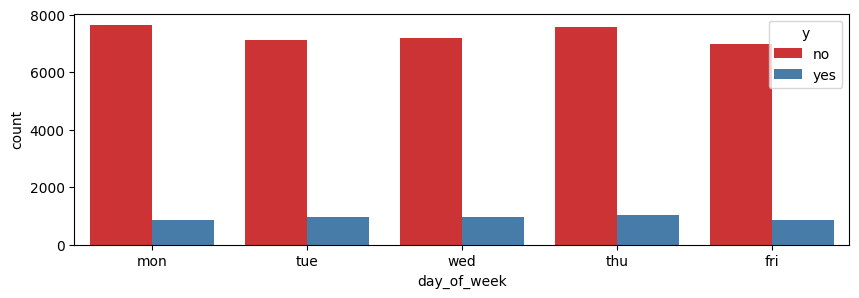

In [308]:
plt.figure(figsize=(10,3))
sns.countplot(data=df,x='day_of_week', hue='y',palette='Set1')

<Axes: xlabel='poutcome', ylabel='count'>

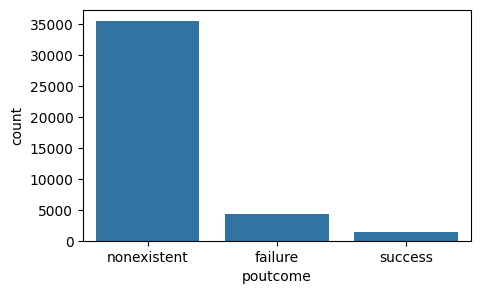

In [309]:
plt.figure(figsize=(5,3))
sns.countplot(data=df, x='poutcome')

<Axes: xlabel='poutcome', ylabel='count'>

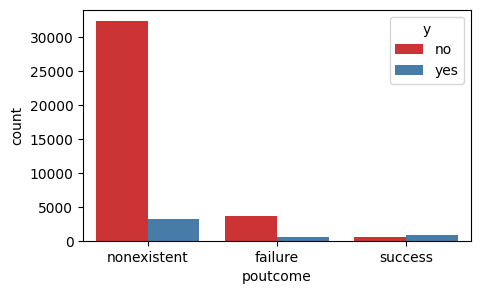

In [310]:
plt.figure(figsize=(5,3))
sns.countplot(data=df,x='poutcome', hue='y',palette='Set1')

In [311]:
# convert the target varible into binary 0-1
df['y'] = df['y'].replace('no',0)
df['y'] = df['y'].replace('yes',1)

In [312]:
from sklearn.preprocessing import OrdinalEncoder

In [313]:
education_order = ['unknown','illiterate','basic.4y','basic.6y','basic.9y','high.school','professional.course','university.degree']
oe = OrdinalEncoder(categories=[education_order])
df['education'] = oe.fit_transform(df[['education']])

In [314]:
df['education'].astype(int)

,education
0,2
1,5
2,5
3,3
4,5
...,...
41183,6
41184,6
41185,7
41186,6


In [315]:
df_cat=df.select_dtypes(exclude=np.number)

In [316]:
df_cat.head()

,job,marital,default,housing,loan,contact,month,day_of_week,poutcome,pdays_category
0,housemaid,married,no,no,no,telephone,may,mon,nonexistent,no contact
1,services,married,unknown,no,no,telephone,may,mon,nonexistent,no contact
2,services,married,no,yes,no,telephone,may,mon,nonexistent,no contact
3,admin.,married,no,no,no,telephone,may,mon,nonexistent,no contact
4,services,married,no,no,yes,telephone,may,mon,nonexistent,no contact


In [317]:
df_cat_1=pd.get_dummies(df_cat,drop_first=True,dtype=int)

In [318]:
df_cat_1.columns

Index(['job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'marital_unknown',
       'default_unknown', 'default_yes', 'housing_unknown', 'housing_yes',
       'loan_unknown', 'loan_yes', 'contact_telephone', 'month_aug',
       'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may',
       'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon',
       'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed',
       'poutcome_nonexistent', 'poutcome_success', 'pdays_category_moderate',
       'pdays_category_no contact', 'pdays_category_recent'],
      dtype='object')

In [319]:
df_transformed = pd.concat([df_cat_1, df.select_dtypes(include=np.number)], axis=1)

In [320]:
df_transformed.head(10)

,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,...,education,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,0,0,1,0,0,0,0,0,0,0,...,2.0,261,1,0,1.1,93.994,-36.4,4.857,5191.0,0
1,0,0,0,0,0,0,1,0,0,0,...,5.0,149,1,0,1.1,93.994,-36.4,4.857,5191.0,0
2,0,0,0,0,0,0,1,0,0,0,...,5.0,226,1,0,1.1,93.994,-36.4,4.857,5191.0,0
3,0,0,0,0,0,0,0,0,0,0,...,3.0,151,1,0,1.1,93.994,-36.4,4.857,5191.0,0
4,0,0,0,0,0,0,1,0,0,0,...,5.0,307,1,0,1.1,93.994,-36.4,4.857,5191.0,0
5,0,0,0,0,0,0,1,0,0,0,...,4.0,198,1,0,1.1,93.994,-36.4,4.857,5191.0,0
6,0,0,0,0,0,0,0,0,0,0,...,6.0,139,1,0,1.1,93.994,-36.4,4.857,5191.0,0
7,1,0,0,0,0,0,0,0,0,0,...,0.0,217,1,0,1.1,93.994,-36.4,4.857,5191.0,0
8,0,0,0,0,0,0,0,0,1,0,...,6.0,380,1,0,1.1,93.994,-36.4,4.857,5191.0,0
9,0,0,0,0,0,0,1,0,0,0,...,5.0,50,1,0,1.1,93.994,-36.4,4.857,5191.0,0


In [321]:
df_transformed.to_csv('bank_data_transformed.csv')

In [322]:
df_1 = df_transformed.drop('y', axis=1)
y = df_transformed['y']


Removing multicollinearity

In [323]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

df_1 = add_constant(df_1)
vif = pd.DataFrame()
vif['Feature'] = df_1.columns
vif['VIF_Factor'] = [variance_inflation_factor(df_1.values, i) for i in range(df_1.shape[1])]
vif = vif[vif['Feature'] != 'const']
print(vif[vif['VIF_Factor'] > 10])

                      Feature  VIF_Factor
17            housing_unknown         inf
19               loan_unknown         inf
22                  month_aug   10.546916
36           poutcome_success   12.606580
37    pdays_category_moderate   42.027636
38  pdays_category_no contact  189.724272
39      pdays_category_recent  145.521243
45               emp.var.rate  238.495070
46             cons.price.idx   89.613599
48                  euribor3m  198.573247
49                nr.employed  199.925049


In [324]:
df_1= df_1.drop('housing_unknown', axis=1)
df_1 = add_constant(df_1)
vif = pd.DataFrame()
vif['Feature'] = df_1.columns
vif['VIF_Factor'] = [variance_inflation_factor(df_1.values, i) for i in range(df_1.shape[1])]
vif = vif[vif['Feature'] != 'const']
print(vif[vif['VIF_Factor'] > 10])

                      Feature  VIF_Factor
21                  month_aug   10.546916
35           poutcome_success   12.606580
36    pdays_category_moderate   42.027636
37  pdays_category_no contact  189.724272
38      pdays_category_recent  145.521243
44               emp.var.rate  238.495070
45             cons.price.idx   89.613599
47                  euribor3m  198.573247
48                nr.employed  199.925049


In [325]:
df_1 = df_1.drop('emp.var.rate', axis=1)
df_1 = add_constant(df_1)
vif = pd.DataFrame()
vif['Feature'] = df_1.columns
vif['VIF_Factor'] = [variance_inflation_factor(df_1.values, i) for i in range(df_1.shape[1])]
vif = vif[vif['Feature'] != 'const']
print(vif[vif['VIF_Factor'] > 10])

                      Feature  VIF_Factor
35           poutcome_success   12.600210
36    pdays_category_moderate   42.027430
37  pdays_category_no contact  189.723992
38      pdays_category_recent  145.515275
44             cons.price.idx   25.777902
46                  euribor3m  195.112728
47                nr.employed  125.656010


In [326]:
df_1 = df_1.drop('euribor3m', axis=1)
df_1 = add_constant(df_1)
vif = pd.DataFrame()
vif['Feature'] = df_1.columns
vif['VIF_Factor'] = [variance_inflation_factor(df_1.values, i) for i in range(df_1.shape[1])]
vif = vif[vif['Feature'] != 'const']
print(vif[vif['VIF_Factor'] > 10])

                      Feature  VIF_Factor
35           poutcome_success   12.600198
36    pdays_category_moderate   42.023054
37  pdays_category_no contact  189.708246
38      pdays_category_recent  145.504476


In [327]:
df_1 = df_1.drop('pdays_category_no contact', axis=1)
df_1 = add_constant(df_1)
vif = pd.DataFrame()
vif['Feature'] = df_1.columns
vif['VIF_Factor'] = [variance_inflation_factor(df_1.values, i) for i in range(df_1.shape[1])]
vif = vif[vif['Feature'] != 'const']
print(vif[vif['VIF_Factor'] > 10])

                  Feature  VIF_Factor
35       poutcome_success   12.205738
37  pdays_category_recent   11.836243


In [328]:
df_1 = df_1.drop('poutcome_success', axis=1)
df_1 = add_constant(df_1)
vif = pd.DataFrame()
vif['Feature'] = df_1.columns
vif['VIF_Factor'] = [variance_inflation_factor(df_1.values, i) for i in range(df_1.shape[1])]
vif = vif[vif['Feature'] != 'const']
print(vif[vif['VIF_Factor'] > 10])

Empty DataFrame
Columns: [Feature, VIF_Factor]
Index: []


In [329]:
df_1 = add_constant(df_1)
vif = pd.DataFrame()
vif['Feature'] = df_1.columns
vif['VIF_Factor'] = [variance_inflation_factor(df_1.values, i) for i in range(df_1.shape[1])]
vif = vif[vif['Feature'] != 'const']
print(vif)

                    Feature  VIF_Factor
1           job_blue-collar    2.000641
2          job_entrepreneur    1.127886
3             job_housemaid    1.142853
4            job_management    1.224726
5               job_retired    1.451253
6         job_self-employed    1.104205
7              job_services    1.327562
8               job_student    1.189957
9            job_technician    1.389871
10           job_unemployed    1.085679
11              job_unknown    1.067772
12          marital_married    2.592609
13           marital_single    2.898935
14          marital_unknown    1.020527
15          default_unknown    1.150383
16              default_yes    1.001171
17              housing_yes    1.041423
18             loan_unknown    1.032131
19                 loan_yes    1.008049
20        contact_telephone    3.297744
21                month_aug    5.328073
22                month_dec    1.140643
23                month_jul    4.474817
24                month_jun    3.476902


Checking for influential points

In [330]:
import statsmodels.api as sm
from statsmodels.graphics.regressionplots import influence_plot

In [332]:
model = sm.Logit(y, df_1).fit(maxiter=1000)
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.209482
         Iterations 57
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                41176
Model:                          Logit   Df Residuals:                    41131
Method:                           MLE   Df Model:                           44
Date:                Sun, 13 Jul 2025   Pseudo R-squ.:                  0.4050
Time:                        14:58:17   Log-Likelihood:                -8625.6
converged:                       True   LL-Null:                       -14496.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      87.2022      4.198     20.771      0.000      78.974  

In [333]:
# Predict probabilities
y_prob = model.predict()

# Convert to binary using threshold = 0.5
y_pred = (y_prob >= 0.5).astype(int)

In [334]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

def evaluate_model(y_true, y_pred, y_prob, name="Model"):
    print(f"\n Evaluation for {name}:\n")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print(f"ROC AUC Score: {roc_auc_score(y_true, y_prob):.4f}")

# Evaluate model
evaluate_model(y, y_pred, y_prob, name="Logit Model")


 Evaluation for Logit Model:

Confusion Matrix:
[[35550   987]
 [ 2694  1945]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     36537
           1       0.66      0.42      0.51      4639

    accuracy                           0.91     41176
   macro avg       0.80      0.70      0.73     41176
weighted avg       0.90      0.91      0.90     41176

ROC AUC Score: 0.9334


In [335]:
influence = model.get_influence()
cooks_d, _ = influence.cooks_distance

In [343]:
# Add Cook's distance to the DataFrame
df_1['cooks_distance'] = cooks_d

# Display top 10 influential points
df_1[['cooks_distance']].sort_values(by='cooks_distance', ascending=False).head(10)

,cooks_distance
1608,0.004384
14788,0.004128
14789,0.003647
20779,0.002941
24091,0.002776
39108,0.002335
38550,0.002174
36316,0.002138
40537,0.001936
8528,0.001785


In [344]:
# Cook's distance threshold
cook_threshold = 4 / len(df_1)
print(f"Threshold for Cook Distance = {cook_threshold}")

Threshold for Cook Distance = 9.714396735962697e-05


In [345]:
influential_points = df_1[df_1['cooks_distance'] > cook_threshold]
prop_influential_points = round(100*(len(influential_points) / len(df_1)),1)
print(f'Proportion of highly influential outliers = {prop_influential_points}%')

Proportion of highly influential outliers = 8.9%


In [346]:
from scipy import stats

In [347]:
df_1['std_resid'] = stats.zscore(model.resid_pearson)
df_1['std_resid'] = df_1.loc[:,'std_resid'].apply(lambda x: np.abs(x))

In [348]:
extreme = df_1[(df_1['cooks_distance'] > cook_threshold) &
                       (df_1['std_resid'] > 3)]
prop_extreme = round(100*(len(extreme) / len(df_1)),2)
print(f'Proportion of highly influential outliers = {prop_extreme}%')

Proportion of highly influential outliers = 0.02%


Not many influential data points

Linearity of independent variables and log odds

In [349]:
df_1.columns

Index(['const', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'marital_unknown',
       'default_unknown', 'default_yes', 'housing_yes', 'loan_unknown',
       'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',
       'day_of_week_wed', 'poutcome_nonexistent', 'pdays_category_moderate',
       'pdays_category_recent', 'age', 'education', 'duration', 'campaign',
       'previous', 'cons.price.idx', 'cons.conf.idx', 'nr.employed',
       'cooks_distance', 'std_resid'],
      dtype='object')

In [350]:
df_transformed['cons.conf.idx.trans'] = df_transformed['cons.conf.idx'] + abs(df_transformed['cons.conf.idx'].min()) + 1
df_transformed['previous.trans'] = df_transformed['previous'].replace(0, 1e-6)

In [351]:
continuous_var = ['age', 'duration', 'campaign','previous.trans', 'cons.price.idx', 'cons.conf.idx.trans', 'nr.employed']
# interaction terms: x * log(x)
for col in continuous_var:
     safe_col = df_transformed[col].apply(lambda x: x if x > 0 else 1e-6)  # avoid log(0) or log(negative)
     df_transformed[f'{col}_log'] = df_transformed[col] * np.log(safe_col)

# Combine original and interaction terms
X = df_transformed[continuous_var + [f"{col}_log" for col in continuous_var]]
X = sm.add_constant(X)
y = df_transformed['y']

In [352]:
X = sm.add_constant(X)
logit_model = sm.Logit(y, X).fit(disp=0)
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                41176
Model:                          Logit   Df Residuals:                    41161
Method:                           MLE   Df Model:                           14
Date:                Sun, 13 Jul 2025   Pseudo R-squ.:                 -0.7171
Time:                        15:01:54   Log-Likelihood:                -24891.
converged:                      False   LL-Null:                       -14496.
Covariance Type:            nonrobust   LLR p-value:                     1.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                   -3.592e+05   6959.400    -51.618      0.000   -3.73e+05   -3.46e+05
age                        -1.1012      0.065    -16.848      0.000      -1.229      -0.973


In [353]:
continuous_var = ['age', 'duration', 'campaign','previous', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']
# interaction terms: x ** 2
for col in continuous_var:
    df_transformed[f'{col}_squared'] = df_transformed[col] ** 2
# Combine original and interaction terms
X = df_transformed[continuous_var + [f"{col}_squared" for col in continuous_var]]
y = df_transformed['y']


X = sm.add_constant(X)

# Fit logistic regression
logit_model_square_trans = sm.Logit(y, X).fit(disp=0)
print(logit_model_square_trans.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                41176
Model:                          Logit   Df Residuals:                    41161
Method:                           MLE   Df Model:                           14
Date:                Sun, 13 Jul 2025   Pseudo R-squ.:                  -6.669
Time:                        15:01:59   Log-Likelihood:            -1.1117e+05
converged:                      False   LL-Null:                       -14496.
Covariance Type:            nonrobust   LLR p-value:                     1.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                  -8.948e+05   2.56e+04    -34.935      0.000   -9.45e+05   -8.45e+05
age                       -0.8945      0.035    -25.642      0.000      -0.963      -0.826
dura

categorize the numerical data

In [354]:
import pandas as pd

continuous_var = ['age', 'duration', 'campaign','previous', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']

# Choose number of bins (usually 4–5 for interpretation)
num_bins = 4

# Apply binning and create new columns
for col in continuous_var:
    bin_col = f'{col}_bin'
    df_transformed[bin_col] = pd.qcut(df_transformed[col], q=num_bins, duplicates='drop', labels=False)

df_binned_encoded = pd.get_dummies(df_transformed[[f'{col}_bin' for col in continuous_var]], drop_first=True, dtype=int)

In [355]:
df_2 = df_1.drop(['cooks_distance', 'std_resid','age', 'education', 'duration', 'campaign','previous', 'cons.price.idx', 'cons.conf.idx', 'nr.employed',], axis=1)

In [356]:
df_3 = pd.concat([df_2, df_binned_encoded], axis=1)

In [357]:
df_3.columns

Index(['const', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'marital_unknown',
       'default_unknown', 'default_yes', 'housing_yes', 'loan_unknown',
       'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',
       'day_of_week_wed', 'poutcome_nonexistent', 'pdays_category_moderate',
       'pdays_category_recent', 'age_bin', 'duration_bin', 'campaign_bin',
       'previous_bin', 'cons.price.idx_bin', 'cons.conf.idx_bin',
       'nr.employed_bin'],
      dtype='object')

Logistic model

In [369]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df_3
y = df_transformed['y']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

In [370]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [371]:
y_pred = lr.predict(X_test)
report = classification_report(y_test, y_pred)
print(" Classification Report:\n")
print(report)
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred):.4f}")

 Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7308
           1       0.66      0.36      0.47       928

    accuracy                           0.91      8236
   macro avg       0.79      0.67      0.71      8236
weighted avg       0.89      0.91      0.89      8236

ROC AUC Score: 0.6689


precision, recall, f1-score for 1 is low. This is due to the presence of imbalance in the data.

In [379]:
lr_1 = LogisticRegression(class_weight='balanced')
lr_1.fit(X_train, y_train)

y_pred = lr_1.predict(X_test)
report = classification_report(y_test, y_pred)
print(" Classification Report:\n")
print(report)
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred):.4f}")

 Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.77      0.82       928
           1       0.80      0.90      0.84       928

    accuracy                           0.84      1856
   macro avg       0.84      0.84      0.83      1856
weighted avg       0.84      0.84      0.83      1856

ROC AUC Score: 0.8351


In [395]:
lr_2 = LogisticRegression(class_weight={0:5, 1:7})
lr_2.fit(X_train, y_train)

y_pred = lr_2.predict(X_test)
report = classification_report(y_test, y_pred)
print(" Classification Report:\n")
print(report)
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred):.4f}")

 Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.74      0.82       928
           1       0.78      0.95      0.86       928

    accuracy                           0.84      1856
   macro avg       0.86      0.84      0.84      1856
weighted avg       0.86      0.84      0.84      1856

ROC AUC Score: 0.8416
